<a href="https://colab.research.google.com/github/rociocelestial/Challenge3-Data-Science/blob/main/TelecomX_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛠️ Preparación de los Datos

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Realizando la lectura de los datos

In [2]:
datos = pd.read_csv('/content/datos_tratados.csv')
datos.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
datos.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


🛠️ Pre procesamiento

* Eliminación de Columnas Irrelevantes : que no van influir en nuestro modelo

In [5]:
datos = datos.drop(columns=['CustomerID'])

In [6]:
datos

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


Cambiamos 'No internet service' a 'No' para que no tengan una alta tasa de correlación

In [7]:

cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})


Verificando los datos Nulos

In [8]:
datos.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#Exploración del análisis de datos

1.- Correlación entre variables numérica

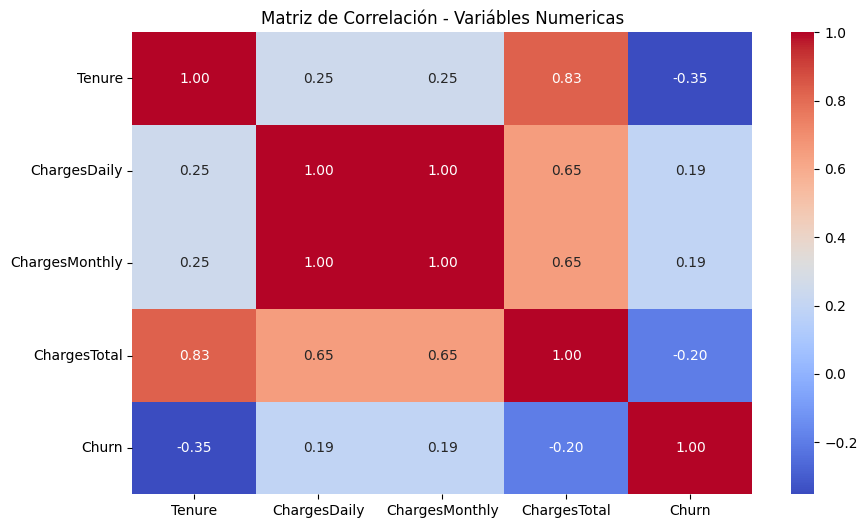

In [9]:
datos_numeric = datos.select_dtypes(include=["int64", "float64"])

datos_numeric["Churn"] = datos["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = datos_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


En esta visualización de la correlación de las variables numéricas nos damos cuenta que existe un correlación alta entre :                     

* 'ChargesDaily' y 'ChargesMonthy', porque son lo mismo, ya que 'ChargesDaily' es la división de 'ChargesMontly entre 30, entonces procedemos a eliminar 'CharlesDaily'

Otra que tiene una correlación alta de 0.83 es:

* 'Tenure' y 'ChargesTotal', aqui procederemos a eliminar 'ChargeTotal' porque ella mantiene una correlación mas elevada con las demas variables que 'Tenure'

In [10]:
datos = datos.drop(columns=['ChargesDaily','ChargesTotal'])

2.- Análisis de Churn por Categorías (variables Categóricas)

Aplicamos el Metodo Chi - square test: para determinar cuales son las variables categóricas significativas

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
datos_tab = datos.copy()

# Convertir Churn para binario
datos_tab["Churn"] = datos_tab["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorica_column = datos_tab.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorica_column:
    datos_tab[col] = le.fit_transform(datos_tab[col])

# Separar X e y
X_cat = datos_tab[categorica_column]
y = datos_tab["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_datos = pd.DataFrame({
    "Variable": categorica_column,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_datos = chi_datos.sort_values(by="Chi2 Score", ascending=False)

chi_datos


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Tabla de las Variables Significativas

In [12]:
significant_vars = chi_datos[chi_datos["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)



✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Esta tabla me indica que las variables Categóricas no significativas son 'Gender' y 'PhoneService', las cuales procedere a eliminar.

In [13]:
datos = datos.drop(columns=['Gender','PhoneService'])

1. Tiempo de contrato vs. Cancelación (Boxplot)

El boxplot es ideal aquí porque te permitirá ver si los clientes que cancelan suelen tener contratos más cortos que los que se quedan.

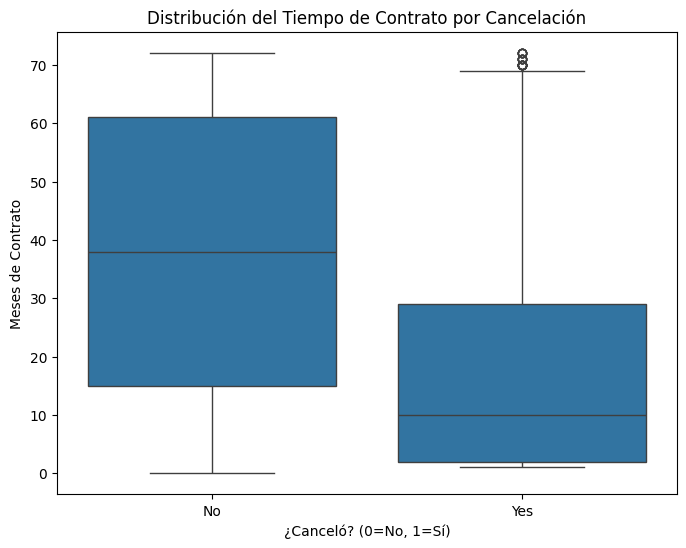

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# 'Churn' es tu columna objetivo y 'Tenure' o 'Tiempo_Contrato' tu variable
sns.boxplot(x='Churn', y='Tenure', data=datos)
plt.title('Distribución del Tiempo de Contrato por Cancelación')
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Meses de Contrato')
plt.show()

2. Gasto Total vs. Cancelación (Boxplot o Histograma)

Para analizar el gasto, un boxplot te mostrará valores atípicos (outliers), mientras que un gráfico de densidad (kdeplot) te mostrará dónde se concentra la mayoría de los pagos.

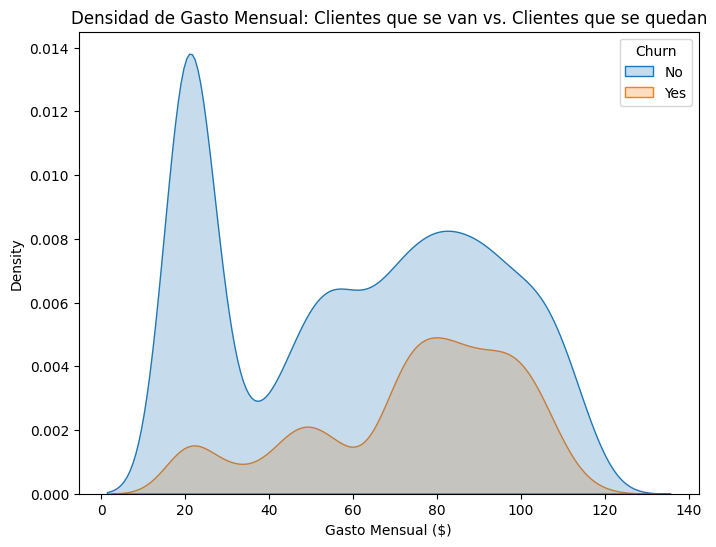

In [15]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=datos, x='ChargesMonthly', hue='Churn', fill=True)
plt.title('Densidad de Gasto Mensual: Clientes que se van vs. Clientes que se quedan')
plt.xlabel('Gasto Mensual ($)')
plt.show()

3. Relación entre Tiempo y Gasto (Scatter Plot)

El scatter plot es útil para ver si existe una correlación. Podemos usar el color (hue) para diferenciar quiénes cancelaron.

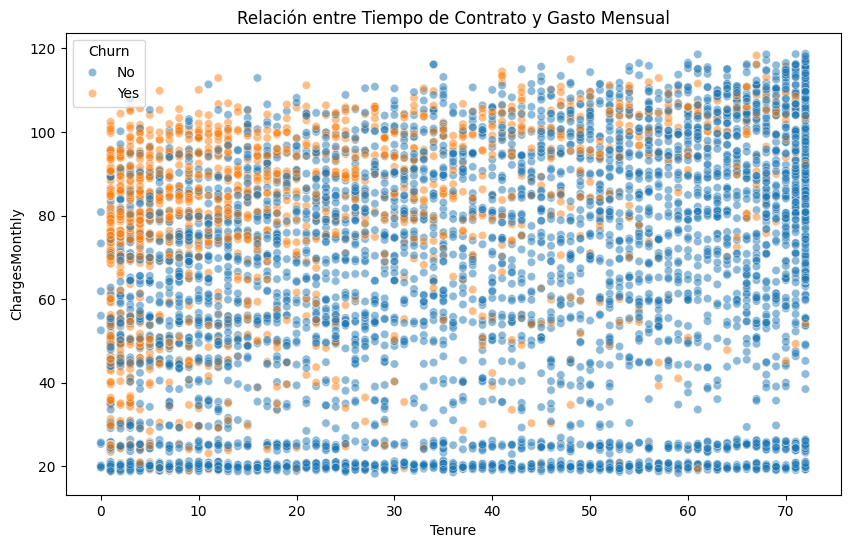

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tenure', y='ChargesMonthly', hue='Churn', data=datos, alpha=0.5)
plt.title('Relación entre Tiempo de Contrato y Gasto Mensual')
plt.show()

#Separo las Variables Explicativas y la Variable Respuesta

In [17]:
X = datos.drop ('Churn', axis=1)
y = datos ['Churn']

In [18]:
X

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


Ajustando el modelo

Separando los datos para Entrenamiento y Prueba



In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

Transformando las Variables Explicativas

In [21]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [22]:
columnas = X.columns

In [23]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),['SeniorCitizen','Partner','Dependents','MultipleLines','InternetService',
                                  'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
                                  'StreamingMovies','Contract','PaperlessBilling','PaymentMethod']),
                                  remainder='passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [24]:
# Transformar X_train y X_test usando el transformer 'one_hot'.
# 'fit_transform' se usa en el conjunto de entrenamiento para aprender los encodings y aplicarlos.
# 'transform' se usa en el conjunto de prueba, aplicando los encodings aprendidos del entrenamiento.
X_train = one_hot.fit_transform(X_train)
X_test = one_hot.transform(X_test)


In [25]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__SeniorCitizen_Yes', 'onehotencoder__Partner_Yes',
       'onehotencoder__Dependents_Yes',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__OnlineSecurity_Yes',
       'onehotencoder__OnlineBackup_Yes',
       'onehotencoder__DeviceProtection_Yes',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_Yes',
       'onehotencoder__StreamingMovies_Yes',
       'onehotencoder__Contract_Month-to-month',
       'onehotencoder__Contract_One year',
       'onehotencoder__Contract_Two year',
       'onehotencoder__PaperlessBilling_Yes',
       'onehotencoder__PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__PaymentMethod_Credit card (automatic)',
       'onehotencoder__PaymentMethod_Electronic check',
       'onehotencoder__PaymentMethod_Mailed check', 'remainder__Tenure',
       'rema

In [39]:
pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas) ).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   onehotencoder__SeniorCitizen_Yes                        0 non-null      float64
 1   onehotencoder__Partner_Yes                              0 non-null      float64
 2   onehotencoder__Dependents_Yes                           0 non-null      float64
 3   onehotencoder__MultipleLines_Yes                        0 non-null      float64
 4   onehotencoder__InternetService_DSL                      0 non-null      float64
 5   onehotencoder__InternetService_Fiber optic              0 non-null      float64
 6   onehotencoder__InternetService_No                       0 non-null      float64
 7   onehotencoder__OnlineSecurity_Yes                       0 non-null      float64
 8   onehotencoder__OnlineBackup_Yes       

Transformando la Variable Respuesta

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
label_encoder = LabelEncoder()

In [29]:
y = label_encoder.fit_transform(y)

In [30]:
y

array([0, 0, 1, ..., 0, 0, 0])

Verificando el Desbalance

In [31]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
No,73.464679
Yes,26.535321


Modelo de referencia: Baseline

In [32]:
from sklearn.dummy import DummyClassifier

In [33]:
dummy = DummyClassifier()
dummy.fit(X_train,y_train)

dummy.score(X_test,y_test)

0.7345635202271115

Normalizando los datos

In [34]:
from sklearn.preprocessing import MinMaxScaler

In [35]:
from sklearn.preprocessing import MinMaxScaler

# Ahora que X_train y X_test ya están transformados (con OneHotEncoder) y son numéricos,
# podemos aplicar MinMaxScaler para normalizar los datos.
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
X_test_normalizado = normalizacion.transform(X_test)

In [42]:
pd.DataFrame(X_train_normalizado, columns = one_hot.get_feature_names_out(columnas) )


,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_Yes,...,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Tenure,remainder__ChargesMonthly
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.833333,0.754360
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.166667,0.009467
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.027778,0.618336
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.458333,0.561535
4,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.194444,0.673642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.305556,0.023418
5630,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.583333,0.755356
5631,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.277778,0.666168
5632,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.333333,0.062780


##Creación de Modelos

Modelo 1 : Regresión Lineal

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

modelo_regresion_lineal = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
modelo_regresion_lineal.fit(X_train,y_train)

y_pred_regresion_lineal = modelo_regresion_lineal.predict(X_test)

print(classification_report(y_test,y_pred_regresion_lineal))


              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



Evaluando el modelo

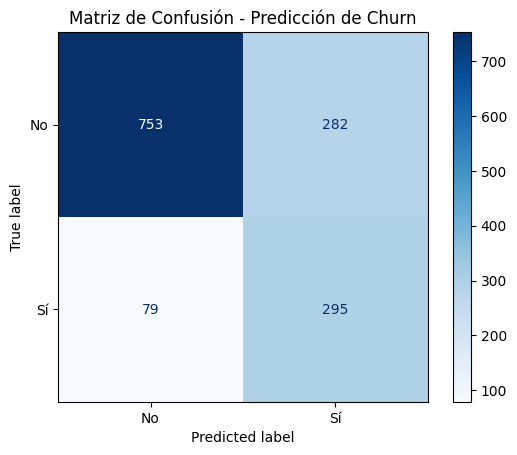

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred_regresion_lineal)

# 2. Configurar la visualización
# display_labels: pon los nombres de tus clases (ej. ['No Churn', 'Churn'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])

# 3. Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

Modelo 2 : Decisión Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

modelo_arbol = DecisionTreeClassifier(class_weight='balanced',max_depth=5,random_state=42)
modelo_arbol.fit(X_train,y_train)

y_pred_modelo_arbol = modelo_arbol.predict(X_test)


print(classification_report(y_test,y_pred_modelo_arbol))


              precision    recall  f1-score   support

          No       0.89      0.76      0.82      1035
         Yes       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



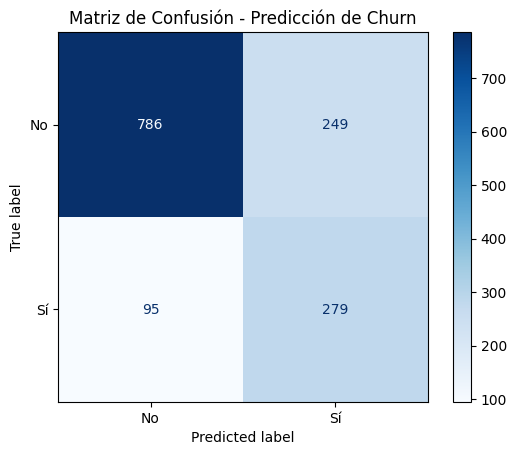

In [54]:
# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred_modelo_arbol)

# 2. Configurar la visualización
# display_labels: pon los nombres de tus clases (ej. ['No Churn', 'Churn'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])

# 3. Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

Modelo 3 : Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


modelo_random_forest = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
modelo_random_forest.fit(X_train,y_train)

y_pred_modelo_random_forest = modelo_random_forest.predict(X_test)


print(classification_report(y_test,y_pred_modelo_random_forest))


              precision    recall  f1-score   support

          No       0.82      0.89      0.85      1035
         Yes       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



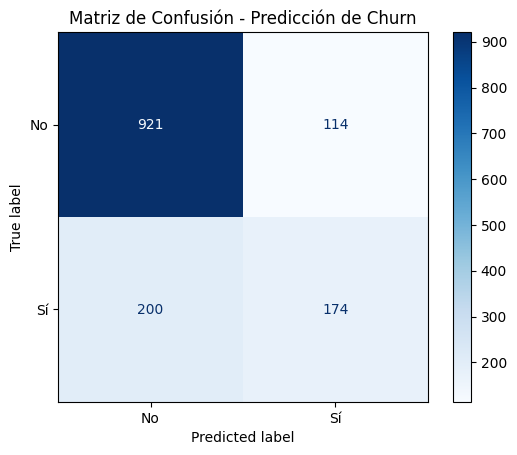

In [52]:
# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred_modelo_random_forest)

# 2. Configurar la visualización
# display_labels: pon los nombres de tus clases (ej. ['No Churn', 'Churn'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])

# 3. Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()